## 1. Import Libraries

In [4]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

In [5]:
base_dir = Path.cwd()
dataset_path = base_dir.parent / 'Assignment-2' / 'dataset' / 'spambase_csv.csv'

if not dataset_path.exists():
    dataset_path = Path(r'd:\\Semester-5\\Machine Learning - Lab\\Assignment-2\\dataset\\spambase_csv.csv')

df = pd.read_csv(dataset_path)
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [6]:
target_column = 'class'
X = df.drop(columns=[target_column])
y = df[target_column]

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (4601, 57)
Target shape: (4601,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (3680, 57) Test size: (921, 57)


In [8]:
baseline_lr = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=2000, random_state=42)),
])

start_time = time.time()
baseline_lr.fit(X_train, y_train)
baseline_lr_time = time.time() - start_time

y_pred_lr_base = baseline_lr.predict(X_test)
y_prob_lr_base = baseline_lr.predict_proba(X_test)[:, 1]

baseline_lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr_base),
    'Precision': precision_score(y_test, y_pred_lr_base),
    'Recall': recall_score(y_test, y_pred_lr_base),
    'F1 Score': f1_score(y_test, y_pred_lr_base),
    'ROC AUC': roc_auc_score(y_test, y_prob_lr_base),
    'Training Time (s)': baseline_lr_time,
}

pd.DataFrame([baseline_lr_metrics])

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,0.929425,0.920904,0.898072,0.909344,0.970196,0.050956


              precision    recall  f1-score   support

         Ham       0.93      0.95      0.94       558
        Spam       0.92      0.90      0.91       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.93       921
weighted avg       0.93      0.93      0.93       921



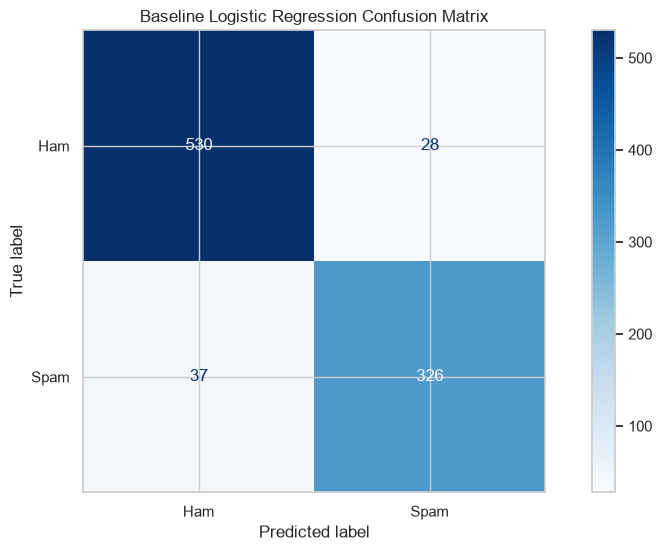

In [9]:
print(classification_report(y_test, y_pred_lr_base, target_names=['Ham', 'Spam']))
cm_lr_base = confusion_matrix(y_test, y_pred_lr_base)
ConfusionMatrixDisplay(cm_lr_base, display_labels=['Ham', 'Spam']).plot(cmap='Blues')
plt.title('Baseline Logistic Regression Confusion Matrix')
plt.show()

In [10]:
lr_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=5000, random_state=42)),
])

lr_param_grid = {
    'model__penalty': ['l1', 'l2'],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['liblinear', 'saga'],
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0,
)

start_time = time.time()
lr_grid.fit(X_train, y_train)
lr_tuning_time = time.time() - start_time

print('Best Logistic Regression Parameters:', lr_grid.best_params_)
print('Best CV Accuracy:', lr_grid.best_score_)

best_lr = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test)
y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

lr_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'F1 Score': f1_score(y_test, y_pred_lr),
    'ROC AUC': roc_auc_score(y_test, y_prob_lr),
    'Training Time (s)': lr_tuning_time,
}

pd.DataFrame([{'Best Params': lr_grid.best_params_, 'Best CV Accuracy': lr_grid.best_score_}])

c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best Logistic Regression Parameters: {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Best CV Accuracy: 0.9266304347826088


,Best Params,Best CV Accuracy
0,"{'model__C': 100, 'model__penalty': 'l1', 'mod...",0.92663


In [11]:
logistic_performance = pd.DataFrame([lr_metrics])
logistic_performance

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,0.926167,0.920228,0.889807,0.904762,0.96786,33.452338


              precision    recall  f1-score   support

         Ham       0.93      0.95      0.94       558
        Spam       0.92      0.89      0.90       363

    accuracy                           0.93       921
   macro avg       0.93      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



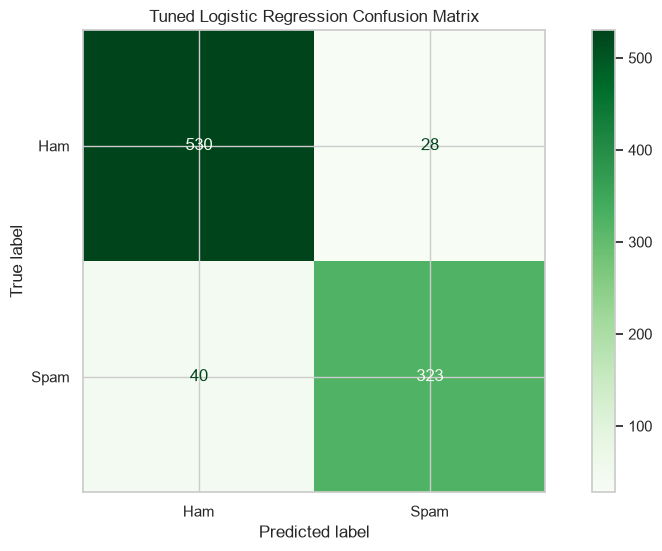

In [12]:
print(classification_report(y_test, y_pred_lr, target_names=['Ham', 'Spam']))
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Ham', 'Spam']).plot(cmap='Greens')
plt.title('Tuned Logistic Regression Confusion Matrix')
plt.show()

In [13]:
svm_kernel_results = []
svm_models = {}
kernel_configs = [
    ('linear', {'kernel': 'linear', 'C': 1.0, 'gamma': 'scale'}),
    ('poly', {'kernel': 'poly', 'C': 1.0, 'gamma': 'scale', 'degree': 3}),
    ('rbf', {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}),
    ('sigmoid', {'kernel': 'sigmoid', 'C': 1.0, 'gamma': 'scale'}),
]

for kernel_name, params in kernel_configs:
    svm_pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', SVC(**params)),
    ])
    start_time = time.time()
    svm_pipeline.fit(X_train, y_train)
    fit_time = time.time() - start_time
    predictions = svm_pipeline.predict(X_test)

    svm_models[kernel_name] = svm_pipeline
    svm_kernel_results.append({
        'Kernel': kernel_name.capitalize(),
        'Accuracy': accuracy_score(y_test, predictions),
        'F1 Score': f1_score(y_test, predictions),
        'Training Time (s)': fit_time,
    })

svm_kernel_results_df = pd.DataFrame(svm_kernel_results)
svm_kernel_results_df

,Kernel,Accuracy,F1 Score,Training Time (s)
0,Linear,0.929425,0.909344,0.405726
1,Poly,0.779587,0.621974,0.321007
2,Rbf,0.927253,0.905501,0.219011
3,Sigmoid,0.884908,0.852778,0.200460


In [14]:
svm_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', SVC()),
])

svm_param_grid = [
    {
        'model__kernel': ['linear'],
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto'],
    },
    {
        'model__kernel': ['poly'],
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto'],
        'model__degree': [2, 3, 4],
    },
    {
        'model__kernel': ['rbf', 'sigmoid'],
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto'],
    },
]

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0,
)

start_time = time.time()
svm_grid.fit(X_train, y_train)
svm_tuning_time = time.time() - start_time

print('Best SVM Parameters:', svm_grid.best_params_)
print('Best CV Accuracy:', svm_grid.best_score_)

best_svm = svm_grid.best_estimator_
y_pred_svm = best_svm.predict(X_test)

svm_probabilities = None
try:
    svm_probabilities = best_svm.decision_function(X_test)
except Exception:
    svm_probabilities = None

svm_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'Precision': precision_score(y_test, y_pred_svm),
    'Recall': recall_score(y_test, y_pred_svm),
    'F1 Score': f1_score(y_test, y_pred_svm),
    'Training Time (s)': svm_tuning_time,
}

pd.DataFrame([{'Best Params': svm_grid.best_params_, 'Best CV Accuracy': svm_grid.best_score_}])

Best SVM Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV Accuracy: 0.9361413043478262


,Best Params,Best CV Accuracy
0,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.936141


In [15]:
svm_performance = pd.DataFrame([svm_metrics])
svm_performance

,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,0.920738,0.914286,0.881543,0.897616,26.89882


              precision    recall  f1-score   support

         Ham       0.92      0.95      0.94       558
        Spam       0.91      0.88      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



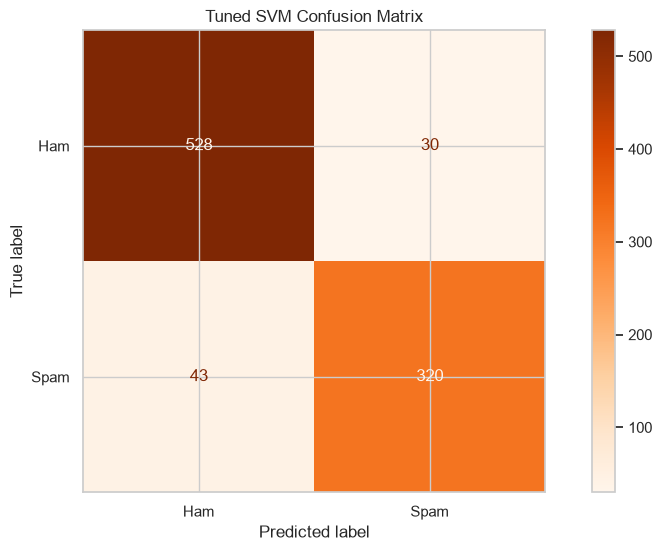

In [16]:
print(classification_report(y_test, y_pred_svm, target_names=['Ham', 'Spam']))
cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=['Ham', 'Spam']).plot(cmap='Oranges')
plt.title('Tuned SVM Confusion Matrix')
plt.show()

In [17]:
lr_cv_scores = cross_val_score(best_lr, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
svm_cv_scores = cross_val_score(best_svm, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

cv_results = pd.DataFrame({
    'Fold': [f'Fold {i}' for i in range(1, 6)] + ['Average'],
    'Logistic Regression': list(np.round(lr_cv_scores, 4)) + [round(lr_cv_scores.mean(), 4)],
    'SVM': list(np.round(svm_cv_scores, 4)) + [round(svm_cv_scores.mean(), 4)],
})
cv_results

,Fold,Logistic Regression,SVM
0,Fold 1,0.9443,0.9429
1,Fold 2,0.9253,0.9457
2,Fold 3,0.9348,0.9334
3,Fold 4,0.9117,0.9307
4,Fold 5,0.9171,0.9280
5,Average,0.9266,0.9361


In [18]:
tuning_summary = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Search Method': 'Grid Search', 'Best Parameters': lr_grid.best_params_, 'Best CV Accuracy': lr_grid.best_score_},
    {'Model': 'SVM', 'Search Method': 'Grid Search', 'Best Parameters': svm_grid.best_params_, 'Best CV Accuracy': svm_grid.best_score_},
])
tuning_summary

,Model,Search Method,Best Parameters,Best CV Accuracy
0,Logistic Regression,Grid Search,"{'model__C': 100, 'model__penalty': 'l1', 'mod...",0.926630
1,SVM,Grid Search,"{'model__C': 10, 'model__gamma': 'scale', 'mod...",0.936141


In [19]:
comparison_table = pd.DataFrame([
    {'Criterion': 'Accuracy', 'Logistic Regression': lr_metrics['Accuracy'], 'SVM': svm_metrics['Accuracy']},
    {'Criterion': 'F1 Score', 'Logistic Regression': lr_metrics['F1 Score'], 'SVM': svm_metrics['F1 Score']},
    {'Criterion': 'Training Time (s)', 'Logistic Regression': lr_metrics['Training Time (s)'], 'SVM': svm_metrics['Training Time (s)']},
    {'Criterion': 'Model Complexity', 'Logistic Regression': 'Low', 'SVM': 'High'},
    {'Criterion': 'Interpretability', 'Logistic Regression': 'High', 'SVM': 'Low'},
])
comparison_table

,Criterion,Logistic Regression,SVM
0,Accuracy,0.926167,0.920738
1,F1 Score,0.904762,0.897616
2,Training Time (s),33.452338,26.89882
3,Model Complexity,Low,High
4,Interpretability,High,Low
